In [1]:
import torch
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath("utils"))

import importlib
import compute_concepts_utils
import patch_alignment_utils
import visualize_concepts_w_samples_utils
import general_utils
import quant_concept_evals_utils 
import superdetector_finetuning_utils
importlib.reload(compute_concepts_utils)
importlib.reload(patch_alignment_utils)
importlib.reload(visualize_concepts_w_samples_utils)
importlib.reload(general_utils)
importlib.reload(quant_concept_evals_utils)
importlib.reload(superdetector_finetuning_utils)

from compute_concepts_utils import compute_linear_separators_w_superpatches_across_pers, plot_train_history, \
     compute_signed_distances
from general_utils import retrieve_topn_samples, load_images
from patch_alignment_utils import compute_heatmaps_for_concept, get_patch_range_for_image
from visualize_concepts_w_samples_utils import plot_patchsims_heatmaps_all_concepts, plot_concept_evolution_over_iterations
from quant_concept_evals_utils import get_patch_detection_tensor, compute_concept_thresholds_over_percentiles
from superdetector_finetuning_utils import compute_f1_over_iterations, plot_f1_over_iterations, \
    compute_linear_separators_finetuned_w_superpatches, plot_all_concepts_metric, \
    plot_weighted_average_metric, plot_best_f1_per_epoch_per_concept, plot_weighted_avg_best_f1_per_epoch, \
    get_best_detect_percentiles_per_epoch_table

# Select Model

In [2]:
MODEL_NAME = 'CLIP'
MODEL_INPUT_SIZE = (224, 224)

In [2]:
MODEL_NAME = 'Llama'
MODEL_INPUT_SIZE = (560, 560)

# Select Dataset

In [4]:
DATASET_NAME = 'CLEVR'

In [3]:
DATASET_NAME = 'Coco'

# Set Files

In [4]:
#linsep
BALANCE_DATA = True
BALANCE_NEGATIVES = False
SAMPLE_TYPE = 'patch'
PERCENT_THRU_MODEL = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMBEDDINGS_FILE = f'{MODEL_NAME}_{SAMPLE_TYPE}_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'

CONCEPTS_FILE = f'iterative_superpatch_linsep_concepts_BD_{BALANCE_DATA}_BN_{BALANCE_NEGATIVES}_{EMBEDDINGS_FILE}'
DISTS_FILE = f'dists_{CONCEPTS_FILE[:-3]}.csv'

ORIGINAL_CONCEPTS_FILE = f'linsep_concepts_BD_{BALANCE_DATA}_BN_{BALANCE_NEGATIVES}_{EMBEDDINGS_FILE}'
ORIGINAL_DISTS_FILE = f'dists_{ORIGINAL_CONCEPTS_FILE[:-3]}.csv'


CON_LABEL = f"iterative_superpatch_{MODEL_NAME}_linsep_{SAMPLE_TYPE}_embeddings_BD_{BALANCE_DATA}_BN_{BALANCE_NEGATIVES}_percentthrumodel_{PERCENT_THRU_MODEL}"

scratch_dir = '/scratch/cgoldberg'

# Retrieve Embeddings

In [5]:
embeds_dic = torch.load(f"{scratch_dir}/Embeddings/{DATASET_NAME}/{EMBEDDINGS_FILE}")
embeds = embeds_dic['normalized_embeddings']
original_dists = pd.read_csv(f"Distances/{DATASET_NAME}/{ORIGINAL_DISTS_FILE}")

# Load GT Information

In [6]:
gt_patches_per_concept = torch.load(f'{scratch_dir}/GT_Samples/{DATASET_NAME}/gt_patches_per_concept_inputsize_{MODEL_INPUT_SIZE}.pt')
gt_patches_per_concept_train = torch.load(f'{scratch_dir}/GT_Samples/{DATASET_NAME}/gt_patch_per_concept_train_inputsize_{MODEL_INPUT_SIZE}.pt')
gt_patches_per_concept_test = torch.load(f'{scratch_dir}/GT_Samples/{DATASET_NAME}/gt_patch_per_concept_test_inputsize_{MODEL_INPUT_SIZE}.pt')

gt_samples_per_concept = torch.load(f'{scratch_dir}/GT_Samples/{DATASET_NAME}/gt_samples_per_concept_inputsize_{MODEL_INPUT_SIZE}.pt')
gt_samples_per_concept_train = torch.load(f'{scratch_dir}/GT_Samples/{DATASET_NAME}/gt_samples_per_concept_train_inputsize_{MODEL_INPUT_SIZE}.pt')
gt_samples_per_concept_test = torch.load(f'{scratch_dir}/GT_Samples/{DATASET_NAME}/gt_samples_per_concept_test_inputsize_{MODEL_INPUT_SIZE}.pt')

# Train linear classifiers from scratch using various percentages of superpatches from prev training

In [136]:
original_dists = pd.read_csv(f"Distances/{DATASET_NAME}/{ORIGINAL_DISTS_FILE}")

In [86]:
top_pers = [0.05, 0.1, 0.2, 0.3, 0.4]
concepts, logs = compute_linear_separators_w_superpatches_across_pers(top_pers, embeds, original_dists, gt_samples_per_concept, DATASET_NAME, 
                                         MODEL_INPUT_SIZE, device=DEVICE, output_file=CONCEPTS_FILE, lr=0.01, 
                                         epochs=100, batch_size=32, patience=15, 
                                          tolerance=3, weight_decay=1e-4, lr_step_size=10, lr_gamma=0.5,
                                          balance_data=BALANCE_DATA, 
                                          balance_negatives=BALANCE_NEGATIVES,
                                          impose_negatives=False)

Computing classifiers using 5.0% superpatches


TypeError: filter_embeddings_by_patch_activations() missing 1 required positional argument: 'model_input_size'

## show various logs

In [ ]:
top_pers = [0.05, 0.1, 0.2]
for top_per in top_pers:
    logs = torch.load(f'Concepts/{DATASET_NAME}/logs_imposeneg_per_{top_per}_{CONCEPTS_FILE}', weights_only=False)
    print(f"\nTop per = {top_per*100}%")
    plot_train_history(logs, metric_type='f1')  

# Train Linear Classifier by Iteratively Dropping Non-Superpatches and Fine-Tuning

## Fine-tuning

In [11]:
# FINE_TUNING_PARAMS = [[('init', 50)],
#                       [('init', 2), (.9, 2), (.8, 2), (.7, 2), (.6, 2), (.5, 2), (.4, 2), (.3, 2), (.2, 2), (.1, 2), (.05, 2)],
#                       [('init', 5), (.75, 5), (.5, 5), (.25, 5), (.05, 5)],
#                       [('init', 5), (.45, 5), (.4, 5), (.35, 5), (.3, 5), (.25, 5), (.2, 5), (.15, 5), (.1, 5), (.05, 5)],
#                       [('init', 5), (.2, 10), (.1, 10), (.05, 10), (.02, 10)],
#                       [('init', 5), (.2, 5), (.1, 5), (.05, 5), (.02, 5)],
#                       [('init', 10), (.2, 10), (.1, 5), (.05, 5), (.02, 5)],
#                       [('init', 1), (.2, 5), (.1, 5), (.05, 5), (.02, 5)],
#                       [('init', 1), (.45, 1), (.4, 1), (.35, 1), (.3, 1), (.25, 1), (.2, 1), (.15, 1), (.1, 1), (.05, 1)],
#                       [('init', 1), (.1, 20)],
#                       [('init', 5), (.2, 10), (.1, 10), (.05, 10), (.02, 10)],
#                       [('init', 2), (.5, 2)]
#                      ]

FINE_TUNING_PARAMS = [[('init', 50)], #0
                      [('init', 2), (.9, 2), (.8, 2), (.7, 2), (.6, 2), (.5, 2), (.4, 2), #1
                       (.3, 2), (.2, 2), (.1, 2), (.05, 2)],
                      [('init', 5), (.75, 5), (.5, 5), (.25, 5), (.05, 5)], #2
                      [('init', 5), (.3, 10), (.2, 10), (.1, 10), (.05, 10)], #3
                      [('init', 1), (.75, 5), (.5, 5), (.25, 5), (.05, 5)] #4
                     ]

fine_tuning_params = FINE_TUNING_PARAMS[1]
fine_tuning_params = [('init', 2), (1, 2)]
baseline_fine_tuning_params = FINE_TUNING_PARAMS[0]


impose_negatives = False
use_gt_labels = True
reset_optimizer = False
highest_negatives = False
add_noise = 0


out = f'finetuned_{fine_tuning_params}_{CONCEPTS_FILE}'
baseline_out = f'finetuned_{baseline_fine_tuning_params}_{CONCEPTS_FILE}'
if add_noise > 0:
    out = f'noise_{add_noise}_' + out
if impose_negatives:
    out = 'impose_neg_' + out
if highest_negatives:
    out = 'highest_neg_' + out
if use_gt_labels:
    out = 'gtlabels_'+ out
    baseline_out = 'gtlabels_'+ baseline_out
if not reset_optimizer:
    out = 'noreset_'+ out
    baseline_out = 'noreset_'+ baseline_out
try:
    model_trainers = torch.load(f'Model_Trainers/{DATASET_NAME}/{out}', map_location=torch.device(DEVICE))
except:
    model_trainers = compute_linear_separators_finetuned_w_superpatches(fine_tuning_params, embeds, 
                                                     gt_patches_per_concept, gt_samples_per_concept_train,
                                                     gt_patches_per_concept_test, gt_samples_per_concept_test,
                                                     DATASET_NAME, MODEL_INPUT_SIZE, device=DEVICE, 
                                                     output_file=CONCEPTS_FILE, lr=0.001, train_batch_size=64, 
                                                     dist_batch_size= 10000, patience=15, tolerance=0.001, 
                                                     weight_decay=0.0001, lr_step_size=5, lr_gamma=0.8,
                                                    balance_data=True, balance_negatives=False, use_gt_labels=True,
                                                     impose_negatives=impose_negatives, reset_optimizer=reset_optimizer, 
                                                     highest_negatives=highest_negatives, add_noise=add_noise,
                                                     temp_file=f'/scratch/cgoldberg/temp/temp3.csv')
baseline_trainers = torch.load(f'Model_Trainers/{DATASET_NAME}/{baseline_out}', map_location=torch.device(DEVICE))

Initial Training
Balancing Just Overall Data
Resampled to 18834 train samples (9417 positive, 9417 negative); 3542 test samples (1771 positive, 1771 negative)
Balancing Just Overall Data
Resampled to 59328 train samples (29664 positive, 29664 negative); 13948 test samples (6974 positive, 6974 negative)
Balancing Just Overall Data
Resampled to 9970 train samples (4985 positive, 4985 negative); 2706 test samples (1353 positive, 1353 negative)
Balancing Just Overall Data
Resampled to 3980 train samples (1990 positive, 1990 negative); 794 test samples (397 positive, 397 negative)
Balancing Just Overall Data
Resampled to 6586 train samples (3293 positive, 3293 negative); 940 test samples (470 positive, 470 negative)
Balancing Just Overall Data
Resampled to 5956 train samples (2978 positive, 2978 negative); 1376 test samples (688 positive, 688 negative)
Balancing Just Overall Data
Resampled to 11016 train samples (5508 positive, 5508 negative); 2782 test samples (1391 positive, 1391 negative

Writing signed distances: 100%|██████████| 128/128 [00:31<00:00,  4.04it/s]


Signed distances saved to /scratch/cgoldberg/temp/temp3.csv


Writing signed distances: 100%|██████████| 128/128 [00:32<00:00,  3.89it/s]


Signed distances saved to /scratch/cgoldberg/temp/temp3.csv
Epoch [2/2] - Train Loss: 0.565380 - Train Acc: 0.7162 - Train F1: 0.7638 | Test Loss: 0.5810 - Test Acc: 0.7050 - Test F1: 0.7503
Epoch [2/2] - Train Loss: 0.441909 - Train Acc: 0.8002 - Train F1: 0.8299 | Test Loss: 0.4457 - Test Acc: 0.7938 - Test F1: 0.8235
Epoch [2/2] - Train Loss: 0.559385 - Train Acc: 0.7633 - Train F1: 0.8040 | Test Loss: 0.5581 - Test Acc: 0.7679 - Test F1: 0.8077
Epoch [2/2] - Train Loss: 0.638402 - Train Acc: 0.7020 - Train F1: 0.7585 | Test Loss: 0.6480 - Test Acc: 0.6788 - Test F1: 0.7330
Epoch [2/2] - Train Loss: 0.595861 - Train Acc: 0.7297 - Train F1: 0.7796 | Test Loss: 0.6012 - Test Acc: 0.7138 - Test F1: 0.7718
Epoch [2/2] - Train Loss: 0.613279 - Train Acc: 0.7292 - Train F1: 0.7777 | Test Loss: 0.6121 - Test Acc: 0.7217 - Test F1: 0.7719
Epoch [2/2] - Train Loss: 0.561540 - Train Acc: 0.7641 - Train F1: 0.8073 | Test Loss: 0.5852 - Test Acc: 0.7610 - Test F1: 0.8026
Epoch [2/2] - Train Los

...

Signed distances saved to /scratch/cgoldberg/temp/temp3.csv
Fine tuning model with top 100% of superpatches
Fine-tuning concept accessory 18834 training samples, 3542 test samples
Fine-tuning concept animal 59328 training samples, 13948 test samples
Fine-tuning concept appliance 9970 training samples, 2706 test samples
Fine-tuning concept bench 3980 training samples, 794 test samples
Fine-tuning concept book 6586 training samples, 940 test samples
Fine-tuning concept bottle 5956 training samples, 1376 test samples
Fine-tuning concept bowl 11016 training samples, 2782 test samples
Fine-tuning concept bus 5674 training samples, 728 test samples
Fine-tuning concept car 15780 training samples, 3996 test samples
Fine-tuning concept chair 17962 training samples, 4224 test samples
Fine-tuning concept couch 4670 training samples, 1692 test samples
Fine-tuning concept cup 5988 training samples, 1656 test samples
Fine-tuning concept dining table 11242 training samples, 2204 test samples
Fine-tun

Writing signed distances: 100%|██████████| 128/128 [00:33<00:00,  3.88it/s]


Signed distances saved to /scratch/cgoldberg/temp/temp3.csv
Epoch [2/2] - Train Loss: 0.524581 - Train Acc: 0.7387 - Train F1: 0.7821 | Test Loss: 0.5440 - Test Acc: 0.7228 - Test F1: 0.7665
Epoch [2/2] - Train Loss: 0.423805 - Train Acc: 0.8122 - Train F1: 0.8398 | Test Loss: 0.4312 - Test Acc: 0.8067 - Test F1: 0.8338
Epoch [2/2] - Train Loss: 0.509605 - Train Acc: 0.7661 - Train F1: 0.8093 | Test Loss: 0.5084 - Test Acc: 0.7735 - Test F1: 0.8143
Epoch [2/2] - Train Loss: 0.600490 - Train Acc: 0.7093 - Train F1: 0.7648 | Test Loss: 0.6230 - Test Acc: 0.6637 - Test F1: 0.7245
Epoch [2/2] - Train Loss: 0.549104 - Train Acc: 0.7431 - Train F1: 0.7899 | Test Loss: 0.5517 - Test Acc: 0.7521 - Test F1: 0.7986
Epoch [2/2] - Train Loss: 0.571006 - Train Acc: 0.7435 - Train F1: 0.7871 | Test Loss: 0.5686 - Test Acc: 0.7398 - Test F1: 0.7841
Epoch [2/2] - Train Loss: 0.507092 - Train Acc: 0.7701 - Train F1: 0.8117 | Test Loss: 0.5431 - Test Acc: 0.7674 - Test F1: 0.8077
Epoch [2/2] - Train Los

Writing signed distances: 100%|██████████| 128/128 [00:32<00:00,  3.88it/s]


Signed distances saved to /scratch/cgoldberg/temp/temp3.csv
Concept trainers saved to Model_Trainers/Coco/noreset_gtlabels_finetuned_[('init', 2), (1, 2)]_iterative_superpatch_linsep_concepts_BD_True_BN_False_CLIP_patch_embeddings_percentthrumodel_100.pt :)


## Plot Training Over Logs

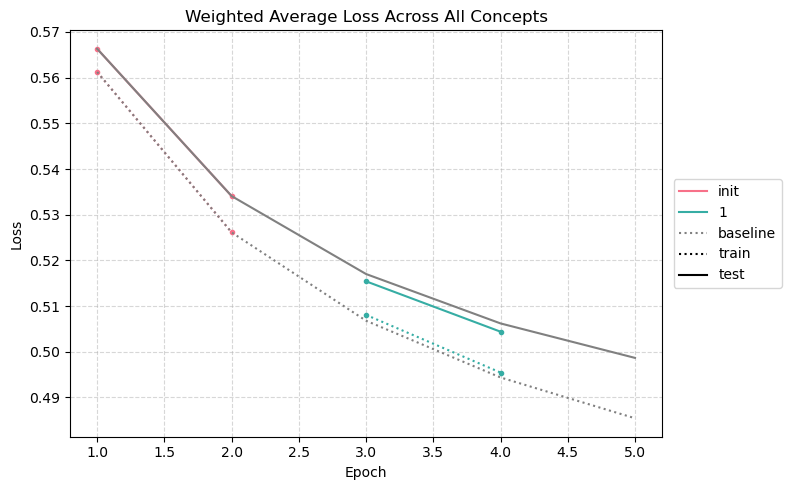

In [12]:
plot_weighted_average_metric(model_trainers, fine_tuning_params, 
                             gt_samples_per_concept, metric_type='loss', 
                             baseline_model_trainers=baseline_trainers, total_epochs=None)

### Per Concept

ValueError: x and y must have same first dimension, but have shapes (2,) and (3,)

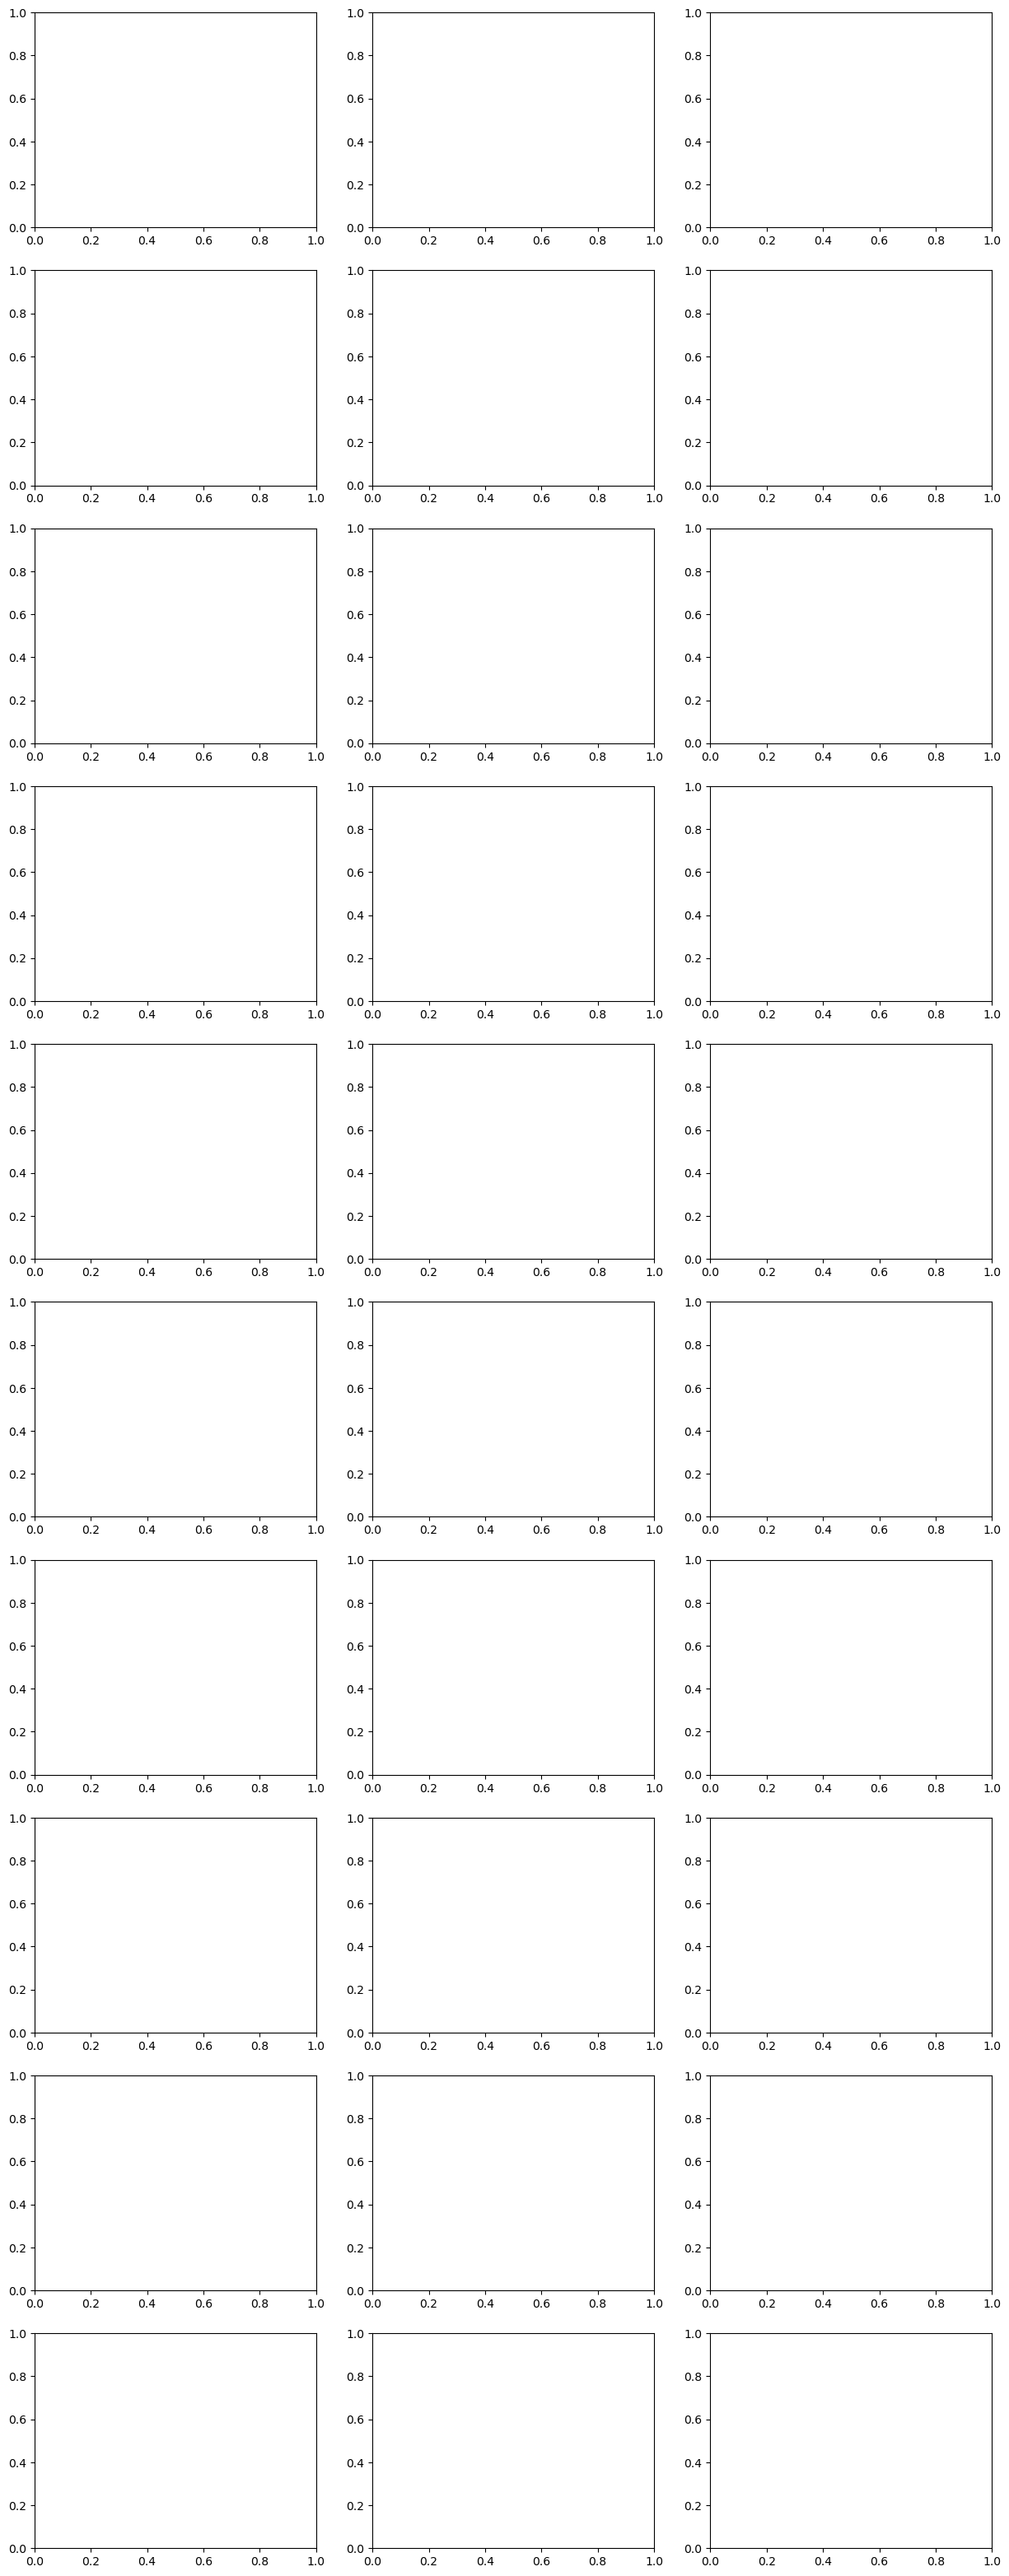

In [116]:
plot_all_concepts_metric(model_trainers, fine_tuning_params, metric_type='loss')

# Compute Detection F1 Over Iterations

## Individual Concept

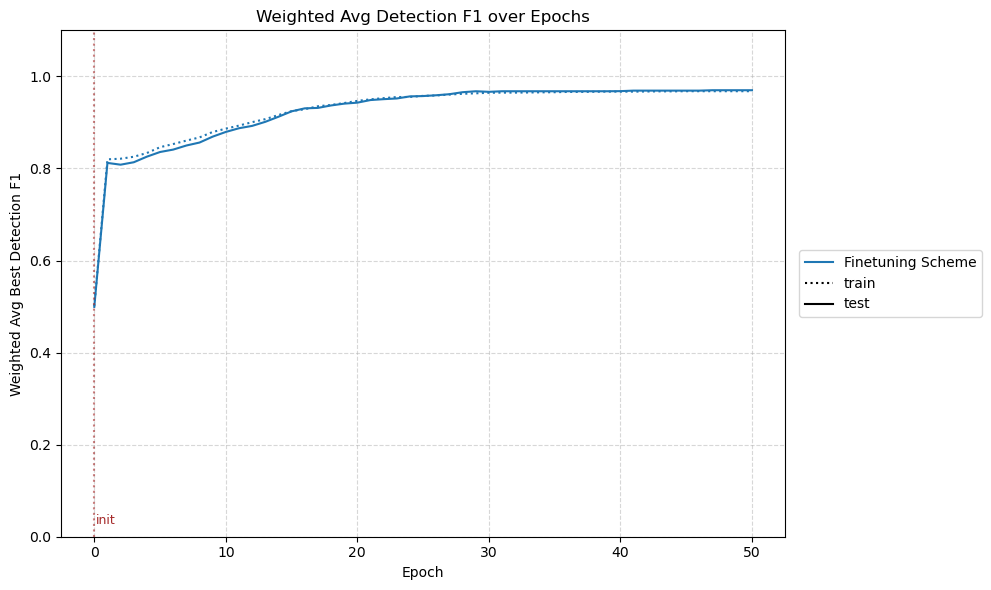

In [10]:
plot_weighted_avg_best_f1_per_epoch(baseline_trainers, baseline_fine_tuning_params, gt_samples_per_concept, max_epoch=None)

## Per Concept

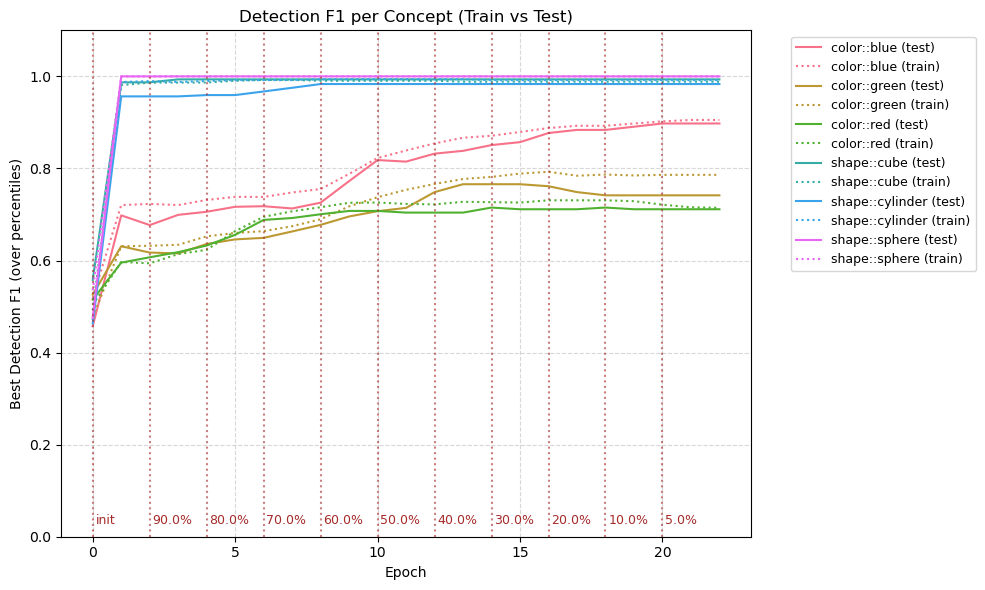

In [11]:
plot_best_f1_per_epoch_per_concept(model_trainers, fine_tuning_params, max_epoch=None)

## Compare to Normal Training

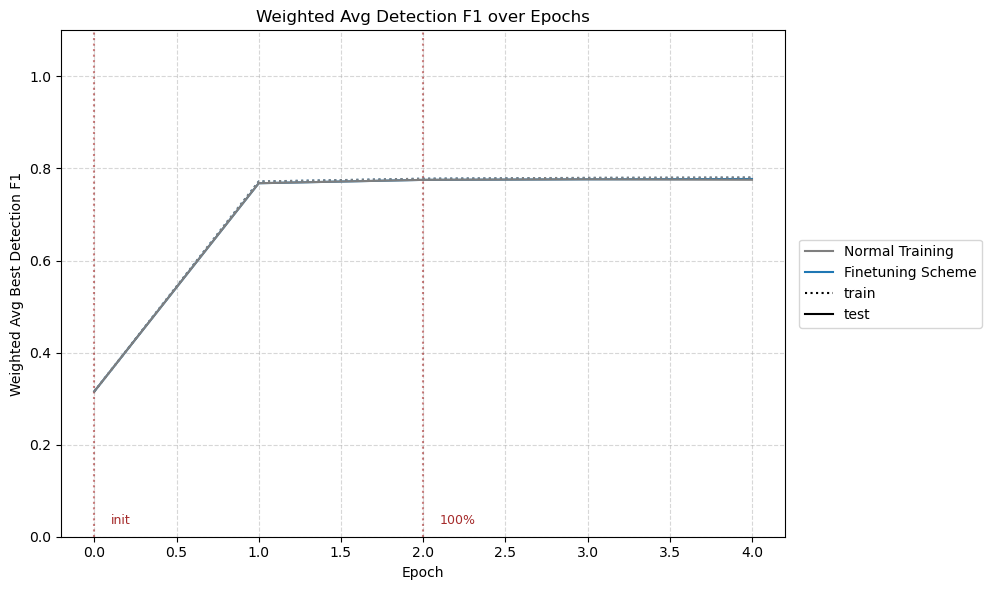

In [14]:
plot_weighted_avg_best_f1_per_epoch(model_trainers, fine_tuning_params, gt_samples_per_concept, max_epoch=None,
                                               baseline_trainers=baseline_trainers)

## Table Showing Best Detect Percentiles over Epochs

In [35]:
get_best_detect_percentiles_per_epoch_table(model_trainers)

,color::blue,color::green,color::red,shape::cube,shape::cylinder,shape::sphere
Epoch,,,,,,
0,0.02,0.02,0.02,0.02,0.02,0.02
1,0.05,0.10,0.05,0.20,0.10,0.20
2,0.05,0.05,0.10,0.20,0.20,0.05
3,0.05,0.05,0.10,0.20,0.20,0.10
4,0.05,0.05,0.10,0.20,0.20,0.10
5,0.05,0.05,0.10,0.20,0.20,0.10
6,0.05,0.05,0.10,0.20,0.10,0.10
7,0.10,0.10,0.20,0.20,0.20,0.10
8,0.10,0.05,0.20,0.10,0.20,0.10


# Visualize Found Concepts

In [16]:
all_images, train_images, test_images = load_images(dataset_name=DATASET_NAME)

Loading Images: 100%|██████████| 5000/5000 [00:14<00:00, 350.80it/s]

Loaded 5000 images.


## Over Iterations

In [11]:
print(f"fine tuning params: {fine_tuning_params}")

fine tuning params: [('init', 2), (0.9, 2), (0.8, 2), (0.7, 2), (0.6, 2), (0.5, 2), (0.4, 2), (0.3, 2), (0.2, 2), (0.1, 2), (0.05, 2)]


Writing signed distances: 100%|██████████| 3/3 [00:00<00:00, 150.22it/s]


Signed distances saved to Distances/Coco/temp/temp.csv


Writing signed distances: 100%|██████████| 3/3 [00:00<00:00, 237.38it/s]


Signed distances saved to Distances/Coco/temp/temp.csv


Writing signed distances: 100%|██████████| 3/3 [00:00<00:00, 242.64it/s]


Signed distances saved to Distances/Coco/temp/temp.csv


/shared_data0/cgoldberg/Concept_Inversion/Experiments/utils/visualize_concepts_w_samples_utils.py:1259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


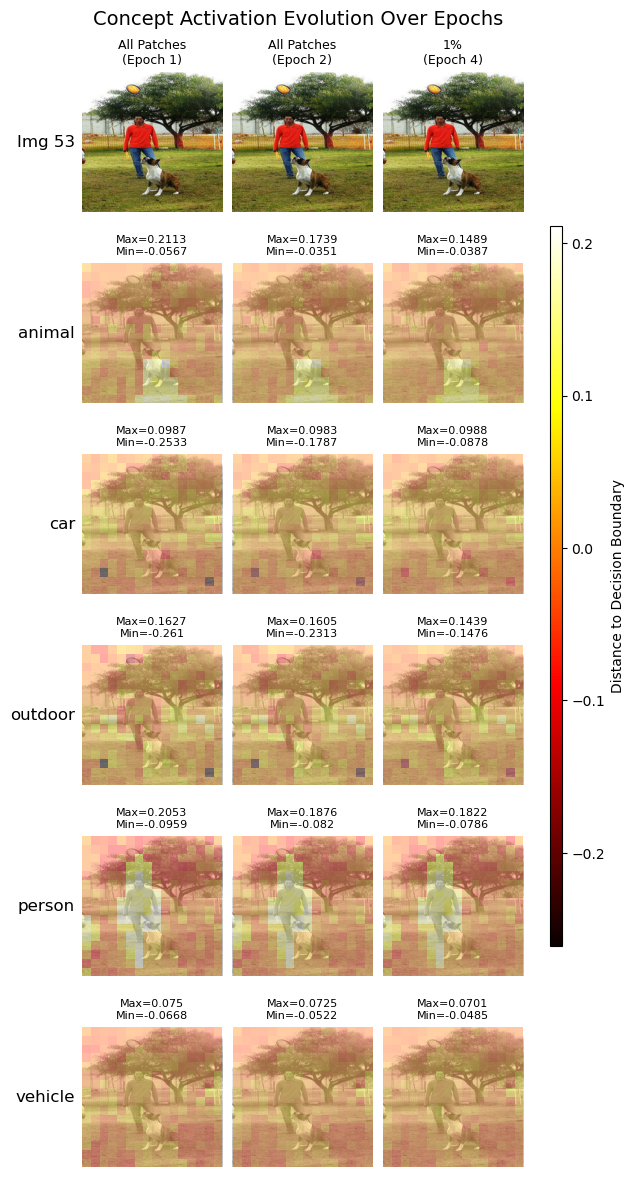

In [17]:
epochs_to_plot = [1]
epochs = 0
for param in fine_tuning_params:
    epochs += param[1]
    if epochs not in epochs_to_plot:
        epochs_to_plot.append(epochs)

top_n = 1
image_indices = retrieve_topn_samples(DATASET_NAME, top_n, start_idx=10, split='test')
image_index = image_indices[0]  # Visualize only this one image

patch_start, patch_end = get_patch_range_for_image(image_index, patch_size=14, model_input_size=MODEL_INPUT_SIZE)
relevant_embeds = embeds[patch_start: patch_end]
patches_per_row = MODEL_INPUT_SIZE[0] // 14
patches_per_col = MODEL_INPUT_SIZE[1] // 14

# Pre-allocate storage
concept_labels = list(gt_samples_per_concept.keys())

if DATASET_NAME == 'Coco':
    concept_labels = [c for c in concept_labels if c in ['animal', 'person', 'vehicle', 'car', 'outdoor']]

all_heatmaps = {concept_label: [] for concept_label in concept_labels}


# Compute heatmaps for all iterations
for iteration in epochs_to_plot:
    concepts = {}
    for c, model_trainer in model_trainers.items():
        try:
            concepts[c] = (model_trainer.get_weight_at_iteration_i(iteration))
        except:
            concepts[c] = (model_trainer.get_most_recent_weights())
    # concepts = {c: model_trainer.get_weight_at_iteration_i(iteration) for c, model_trainer in model_trainers.items()}
    
    
    compute_signed_distances(
        relevant_embeds, concepts, DATASET_NAME, DEVICE, output_file='temp/temp.csv', batch_size=100
    )
    sim_metrics = pd.read_csv(f'Distances/{DATASET_NAME}/temp/temp.csv')

    for concept_label in concept_labels:
        # Handle case where some concepts aren't in earlier iterations
        if concept_label not in concepts:
            all_heatmaps[concept_label].append(torch.zeros((MODEL_INPUT_SIZE[0] // 14, MODEL_INPUT_SIZE[1] // 14)))
            continue
        
        # Reshape similarities to match the patch grid
        cos_sim_grid = sim_metrics[concept_label].values.reshape(patches_per_col, patches_per_row)

        # Plot the heatmap
        heatmap = torch.tensor(cos_sim_grid)

        all_heatmaps[concept_label].append(heatmap)
    del sim_metrics

# Now plot using the heatmaps directly
plot_concept_evolution_over_iterations(
    image_index=image_index,
    heatmaps_over_time=all_heatmaps,
    all_images=all_images,
    dataset_name=DATASET_NAME,
    model_input_size=MODEL_INPUT_SIZE,
    concept_labels=concept_labels,
    fine_tuning_params=fine_tuning_params,
    top_n=top_n,
    metric_type='Distance to Decision Boundary',
    epochs_to_plot = epochs_to_plot
)